In [ ]:
!unzip Images_7.zip

Archive:  Images_7.zip
   creating: Images_7/
   creating: Images_7/New_7_classes/
   creating: Images_7/New_7_classes/angry/
  inflating: Images_7/New_7_classes/angry/0_0.jpg  
  inflating: Images_7/New_7_classes/angry/0_25.jpg  
  inflating: Images_7/New_7_classes/angry/0_29.jpg  
  inflating: Images_7/New_7_classes/angry/100_22.jpg  
  inflating: Images_7/New_7_classes/angry/100_24.jpg  
  inflating: Images_7/New_7_classes/angry/100_29.jpg  
  inflating: Images_7/New_7_classes/angry/101_19.jpg  
  inflating: Images_7/New_7_classes/angry/101_3.jpg  
  inflating: Images_7/New_7_classes/angry/101_32.jpg  
  inflating: Images_7/New_7_classes/angry/102_17.jpg  
  inflating: Images_7/New_7_classes/angry/102_20.jpg  
  inflating: Images_7/New_7_classes/angry/102_34.jpg  
  inflating: Images_7/New_7_classes/angry/103_16.jpg  
  inflating: Images_7/New_7_classes/angry/103_23.jpg  
  inflating: Images_7/New_7_classes/angry/103_32.jpg  
  inflating: Images_7/New_7_classes/angry/104_11.jpg  
  

Class-wise Distribution:

surprise: 419
disgust: 420
angry: 420
sad: 419
fear: 420
happy: 420
neutral: 420
surprise → Saved 419
disgust → Saved 420
angry → Saved 420
sad → Saved 419
fear → Saved 420
happy → Saved 420
neutral → Saved 420
surprise: Train=335, Validation=84
disgust: Train=336, Validation=84
angry: Train=336, Validation=84
sad: Train=335, Validation=84
fear: Train=336, Validation=84
happy: Train=336, Validation=84
neutral: Train=336, Validation=84


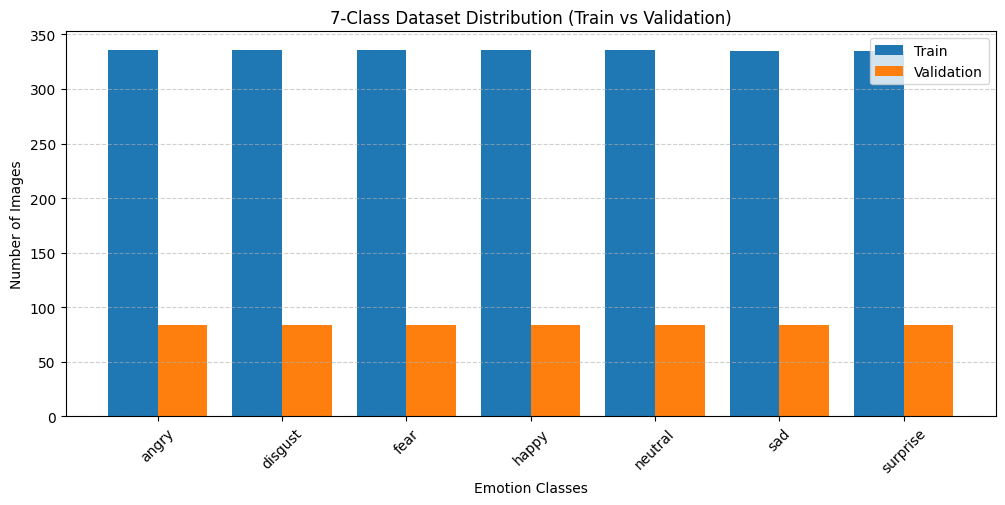

In [ ]:
import os

DATASET_DIR = "Images_7/New_7_classes"

class_counts = {}
for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

print("Class-wise Distribution:\n")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

!pip install opencv-python-headless
import os
import cv2

SOURCE_DIR = "/content/Images_7/New_7_classes"
TARGET_DIR = "/content/Images_7_updated"

os.makedirs(TARGET_DIR, exist_ok=True)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Create class folders
for cls in os.listdir(SOURCE_DIR):
    os.makedirs(os.path.join(TARGET_DIR, cls), exist_ok=True)


def crop_face(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(120, 120)
    )

    h_img, w_img, _ = img.shape

    # Fallback center crop (rare)
    if len(faces) == 0:
        size = int(min(h_img, w_img) * 0.5)
        cy, cx = h_img // 2, w_img // 2
        y1 = max(0, cy - size//2)
        y2 = min(h_img, cy + size//2)
        x1 = max(0, cx - size//2)
        x2 = min(w_img, cx + size//2)
        crop = img[y1:y2, x1:x2]
        return cv2.resize(crop, (224,224))

    # Largest face
    faces = sorted(faces, key=lambda x: x[2]*x[3], reverse=True)
    x, y, w, h = faces[0]

    # 🎯 Balanced tuning
    top_crop = int(0.18 * h)        # remove hair
    bottom_expand = int(0.08 * h)   # keep chin
    side_expand = int(0.05 * w)     # cheeks

    x1 = max(0, x - side_expand)
    y1 = max(0, y + top_crop)
    x2 = min(w_img, x + w + side_expand)
    y2 = min(h_img, y + h + bottom_expand)

    face_crop = img[y1:y2, x1:x2]

    if face_crop.size == 0:
        return None

    face_crop = cv2.resize(face_crop, (224,224))
    return face_crop


# Process dataset
for cls in os.listdir(SOURCE_DIR):
    cls_path = os.path.join(SOURCE_DIR, cls)
    target_cls_path = os.path.join(TARGET_DIR, cls)

    count = 0

    for img_name in os.listdir(cls_path):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        src = os.path.join(cls_path, img_name)
        crop = crop_face(src)

        if crop is None:
            continue

        save_path = os.path.join(target_cls_path, img_name)
        cv2.imwrite(save_path, crop)
        count += 1

    print(f"{cls} → Saved {count}")
import os
import shutil
import random

SOURCE_DIR = "/content/Images_7_updated"
TARGET_DIR = "/content/Images_7_split"

TRAIN_RATIO = 0.8                  # 80% train, 20% validation


for split in ["train", "validation"]:
    for cls in os.listdir(SOURCE_DIR):
        os.makedirs(os.path.join(TARGET_DIR, split, cls), exist_ok=True)


random.seed(42)  # for reproducibility

for cls in os.listdir(SOURCE_DIR):
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [
        img for img in os.listdir(cls_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)

    split_index = int(len(images) * TRAIN_RATIO)
    train_images = images[:split_index]
    val_images = images[split_index:]

    # Copy train images
    for img in train_images:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(TARGET_DIR, "train", cls, img)
        )

    # Copy validation images
    for img in val_images:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(TARGET_DIR, "validation", cls, img)
        )

    print(f"{cls}: Train={len(train_images)}, Validation={len(val_images)}")

import os
import matplotlib.pyplot as plt

# Paths
DATASET_DIR = "/content/Images_7_split"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")

# Get class names automatically (7 classes)
CLASSES = sorted(os.listdir(TRAIN_DIR))

# Count images
train_counts = {
    cls: len([
        f for f in os.listdir(os.path.join(TRAIN_DIR, cls))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    for cls in CLASSES
}

val_counts = {
    cls: len([
        f for f in os.listdir(os.path.join(VAL_DIR, cls))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    for cls in CLASSES
}

# Plot
plt.figure(figsize=(12,5))
x = range(len(CLASSES))

plt.bar(
    [i - 0.2 for i in x],
    train_counts.values(),
    width=0.4,
    label='Train'
)
plt.bar(
    [i + 0.2 for i in x],
    val_counts.values(),
    width=0.4,
    label='Validation'
)

plt.xticks(x, CLASSES, rotation=45)
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("7-Class Dataset Distribution (Train vs Validation)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 120

TRAIN_DIR = "/content/Images_7_split/train"
VAL_DIR   = "/content/Images_7_split/validation"
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=True
)
print("Class order used during training:", train_ds.class_names)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=False
)

NUM_CLASSES = len(train_ds.class_names)
print("Classes:", train_ds.class_names)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
])
normalization_layer = layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x)), y)
).prefetch(AUTOTUNE)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
).prefetch(AUTOTUNE)

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # 🔥 higher LR
    loss='sparse_categorical_crossentropy',                  # ❌ no label smoothing
    metrics=['accuracy']
)

model.summary()

callbacks = [
    # Stop training when validation stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    # Save best model automatically
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce LR when stuck (VERY important)
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Found 2350 files belonging to 7 classes.
Class order used during training: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Found 588 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,575 (9.36 MB)

 Trainable params: 2,453,575 (9.36 MB)

...


Epoch 41: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8374 - loss: 0.4250 - val_accuracy: 0.8231 - val_loss: 0.5545 - learning_rate: 3.0000e-04
Epoch 42/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8370 - loss: 0.4238
Epoch 42: val_accuracy did not improve from 0.82313
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8409 - loss: 0.4037 - val_accuracy: 0.8095 - val_loss: 0.5317 - learning_rate: 3.0000e-04
Epoch 43/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8374 - loss: 0.4086
Epoch 43: val_accuracy did not improve from 0.82313
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8430 - loss: 0.4039 - val_accuracy: 0.8010 - val_loss: 0.5459 - learning_rate: 3.0000e-04
Epoch 44/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8420 - loss: 0.4292
Epoch 44: val_accuracy did not improve from 0.82313
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8396 - loss: 0.4204 - val_accuracy: 0.8163 - va


Epoch 46: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8634 - loss: 0.3811 - val_accuracy: 0.8248 - val_loss: 0.5017 - learning_rate: 3.0000e-04
Epoch 47/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8512 - loss: 0.3807
Epoch 47: val_accuracy improved from 0.82483 to 0.83163, saving model to best_model.h5



Epoch 47: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8519 - loss: 0.3756 - val_accuracy: 0.8316 - val_loss: 0.5085 - learning_rate: 3.0000e-04
Epoch 48/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8622 - loss: 0.3502
Epoch 48: val_accuracy did not improve from 0.83163
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8634 - loss: 0.3532 - val_accuracy: 0.8316 - val_loss: 0.5329 - learning_rate: 3.0000e-04
Epoch 49/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8640 - loss: 0.3679
Epoch 49: val_accuracy did not improve from 0.83163
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8583 - loss: 0.3689 - val_accuracy: 0.8316 - val_loss: 0.5204 - learning_rate: 3.0000e-04
Epoch 50/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8674 - loss: 0.3678
Epoch 50: val_accuracy did not improve from 0.83163
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8677 - loss: 0.3539 - val_accuracy: 0.7942 - va


Epoch 52: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8851 - loss: 0.3126 - val_accuracy: 0.8367 - val_loss: 0.4602 - learning_rate: 9.0000e-05
Epoch 53/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8739 - loss: 0.3139
Epoch 53: val_accuracy did not improve from 0.83673
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8826 - loss: 0.2990 - val_accuracy: 0.8350 - val_loss: 0.4838 - learning_rate: 9.0000e-05
Epoch 54/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8839 - loss: 0.2916
Epoch 54: val_accuracy did not improve from 0.83673
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8906 - loss: 0.2867 - val_accuracy: 0.8231 - val_loss: 0.5168 - learning_rate: 9.0000e-05
Epoch 55/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8821 - loss: 0.2919
Epoch 55: val_accuracy did not improve from 0.83673
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8911 - loss: 0.2731 - val_accuracy: 0.8367 - va


Epoch 58: finished saving model to best_model.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8991 - loss: 0.2759 - val_accuracy: 0.8418 - val_loss: 0.4853 - learning_rate: 2.7000e-05
Epoch 59/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9082 - loss: 0.2510
Epoch 59: val_accuracy did not improve from 0.84184
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9081 - loss: 0.2498 - val_accuracy: 0.8418 - val_loss: 0.4886 - learning_rate: 2.7000e-05
Epoch 60/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9080 - loss: 0.2708
Epoch 60: val_accuracy did not improve from 0.84184
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9017 - loss: 0.2693 - val_accuracy: 0.8367 - val_loss: 0.4760 - learning_rate: 2.7000e-05
Epoch 61/120
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9164 - loss: 0.2309
Epoch 61: val_accuracy did not improve from 0.84184
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9111 - loss: 0.2463 - val_accuracy: 0.8384 - va

In [ ]:
# =============================
# TOP-K ACCURACY FUNCTION
# =============================
def top_k_accuracy(model, dataset, k=2):
    total = 0
    correct = 0

    for x_batch, y_batch in dataset:
        y_pred = model(x_batch, training=False)

        # Handle both sparse and one-hot labels
        if len(y_batch.shape) > 1 and y_batch.shape[-1] > 1:
            y_true = tf.argmax(y_batch, axis=1)
        else:
            y_true = tf.cast(tf.reshape(y_batch, [-1]), tf.int32)

        top_k = tf.math.top_k(y_pred, k=k).indices
        y_true_expanded = tf.expand_dims(y_true, axis=1)

        matches = tf.reduce_any(tf.equal(top_k, y_true_expanded), axis=1)

        correct += tf.reduce_sum(tf.cast(matches, tf.int32)).numpy()
        total += y_true.shape[0]

    return 100.0 * correct / total


print("\n📊 TRAIN ACCURACY")
for k in [1, 2, 3]:
    acc = top_k_accuracy(model, train_ds, k=k)
    print(f"Top-{k} Accuracy (Train): {acc:.2f}%")

print("\n📊 VALIDATION ACCURACY")
for k in [1, 2, 3]:
    acc = top_k_accuracy(model, val_ds, k=k)
    print(f"Top-{k} Accuracy (Val): {acc:.2f}%")


📊 TRAIN ACCURACY
Top-1 Accuracy (Train): 94.17%
Top-2 Accuracy (Train): 99.32%
Top-3 Accuracy (Train): 99.91%

📊 VALIDATION ACCURACY
Top-1 Accuracy (Val): 83.67%
Top-2 Accuracy (Val): 95.41%
Top-3 Accuracy (Val): 98.47%


Final Training Accuracy     : 0.9123
Final Validation Accuracy   : 0.8401


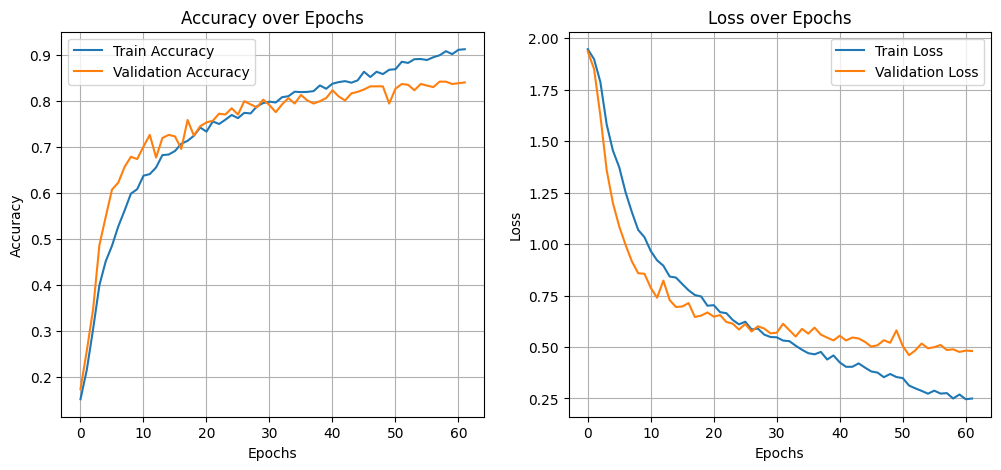

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step


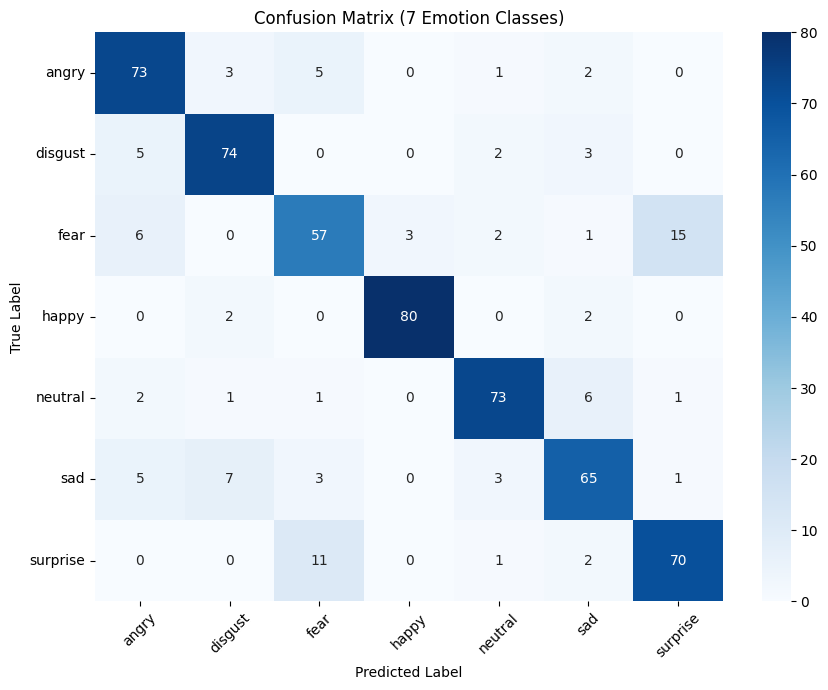

In [ ]:
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy     : {train_acc:.4f}")
print(f"Final Validation Accuracy   : {val_acc:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid(True)

plt.show()

import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# class_names = train_ds.class_names  # 7 class labels

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9,7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (7 Emotion Classes)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Class-wise Precision, Recall, F1
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

       angry     0.8022    0.8690    0.8343        84
     disgust     0.8506    0.8810    0.8655        84
        fear     0.7403    0.6786    0.7081        84
       happy     0.9639    0.9524    0.9581        84
     neutral     0.8902    0.8690    0.8795        84
         sad     0.8025    0.7738    0.7879        84
    surprise     0.8046    0.8333    0.8187        84

    accuracy                         0.8367       588
   macro avg     0.8363    0.8367    0.8360       588
weighted avg     0.8363    0.8367    0.8360       588



Saving angry_2.jpg to angry_2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step


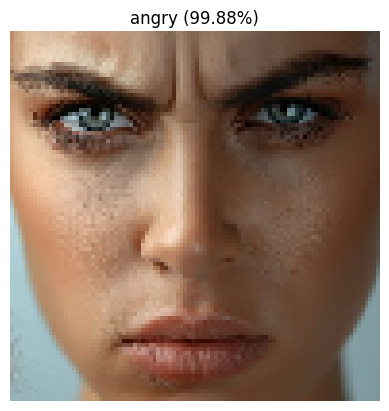

Predicted class : angry
Confidence      : 0.9988


In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # ✅ SAME as training

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    predicted_class = class_names[pred_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

pred_class, conf = predict_image(image_path, model)

print("Predicted class :", pred_class)
print("Confidence      :", f"{conf:.4f}")


Saving happy_2.jpg to happy_2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


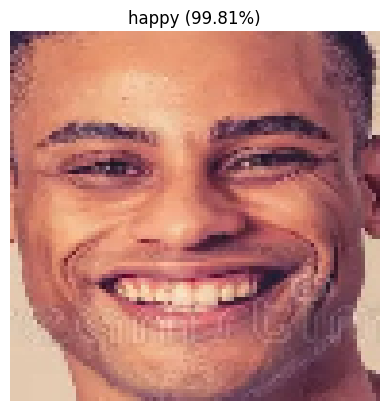

Predicted class : happy
Confidence      : 0.9981


In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # ✅ SAME as training

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    predicted_class = class_names[pred_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

pred_class, conf = predict_image(image_path, model)

print("Predicted class :", pred_class)
print("Confidence      :", f"{conf:.4f}")


Saving disgust_1.jpg to disgust_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


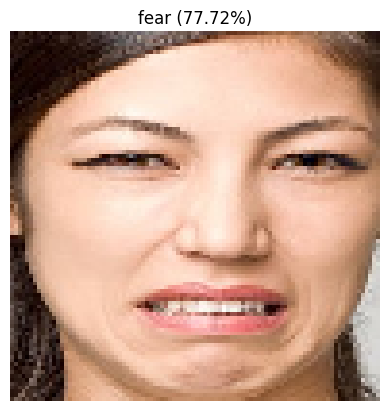

Predicted class : fear
Confidence      : 0.7772


In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # ✅ SAME as training

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    predicted_class = class_names[pred_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

pred_class, conf = predict_image(image_path, model)

print("Predicted class :", pred_class)
print("Confidence      :", f"{conf:.4f}")


Saving fear_1.jpg to fear_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


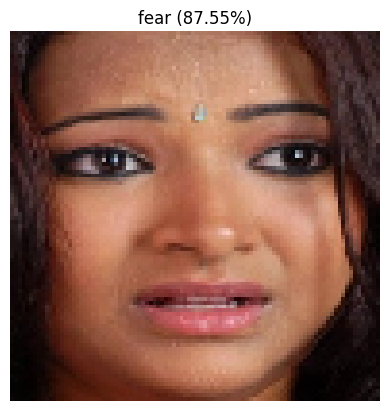

Predicted class : fear
Confidence      : 0.8755


In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # ✅ SAME as training

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    predicted_class = class_names[pred_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

pred_class, conf = predict_image(image_path, model)

print("Predicted class :", pred_class)
print("Confidence      :", f"{conf:.4f}")


Saving sad_3.jpg to sad_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


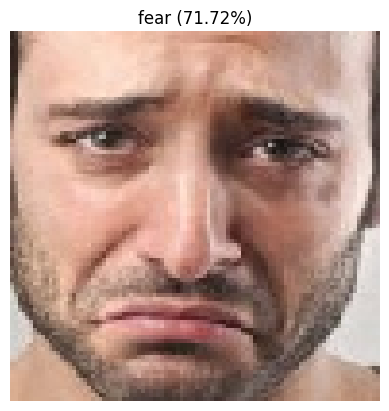

Predicted class : fear
Confidence      : 0.7172


In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # ✅ SAME as training

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    predicted_class = class_names[pred_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

pred_class, conf = predict_image(image_path, model)

print("Predicted class :", pred_class)
print("Confidence      :", f"{conf:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


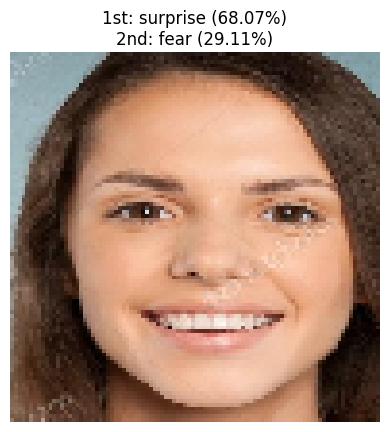

Top 1: surprise (68.07%)
Top 2: fear (29.11%)


In [ ]:
def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)[0]

    # Get top 2 indices
    top_2_idx = np.argsort(preds)[-2:][::-1]

    # Extract class names and confidence
    top_2_classes = [class_names[i] for i in top_2_idx]
    top_2_conf = [preds[i] for i in top_2_idx]

    # Display image
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"1st: {top_2_classes[0]} ({top_2_conf[0]*100:.2f}%)\n"
        f"2nd: {top_2_classes[1]} ({top_2_conf[1]*100:.2f}%)"
    )
    plt.show()

    return top_2_classes, top_2_conf



top_classes, top_conf = predict_image(image_path, model)

print("Top 1:", top_classes[0], f"({top_conf[0]*100:.2f}%)")
print("Top 2:", top_classes[1], f"({top_conf[1]*100:.2f}%)")

Saving disgust_1_1.jpg to disgust_1_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


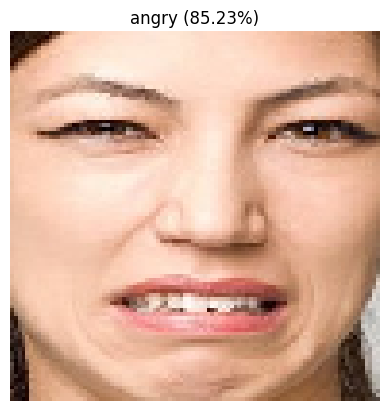

Predicted class : angry
Confidence      : 0.8523


In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # ✅ SAME as training

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    predicted_class = class_names[pred_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

pred_class, conf = predict_image(image_path, model)

print("Predicted class :", pred_class)
print("Confidence      :", f"{conf:.4f}")


Saving sad_5.webp to sad_5.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


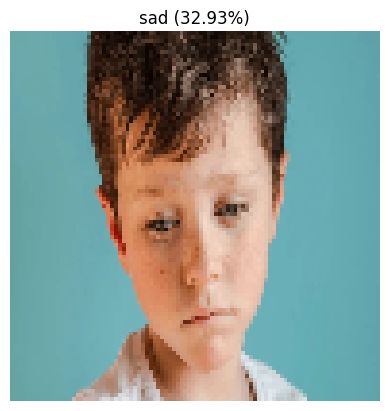

Predicted class : sad
Confidence      : 0.3293


In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # ✅ SAME as training

def preprocess_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

def predict_image(image_path, model):
    img_array, img = preprocess_image(image_path)

    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]

    predicted_class = class_names[pred_idx]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

pred_class, conf = predict_image(image_path, model)

print("Predicted class :", pred_class)
print("Confidence      :", f"{conf:.4f}")


In [ ]:
model.save("emotion_model.h5")